<a href="https://colab.research.google.com/github/CPTR295/Sample-LLMs/blob/main/Pretraining_on_Unlabeled_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader

In [32]:
#Dataset class
class GPTDataset(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
      self.input_ids=[]
      self.target_ids=[]

      #Tokenizze the text
      token_ids = tokenizer.encode(txt,allowed_special={"<|endoftext|>"})
      #Use sliding window to create input and target
      for i in range(0,len(token_ids)-max_length,stride):
        input_chunk = token_ids[i:i+max_length]
        target_chunk = token_ids[i+1:i+max_length+1]
        self.input_ids.append(torch.tensor(input_chunk))
        self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
      return len(self.input_ids)
    def __getitem__(self, idx):
      return self.input_ids[idx],self.target_ids[idx]

In [33]:
#DataLoader
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDataset(txt,tokenizer,max_length,stride)
  dataloader = DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)
  return dataloader

In [34]:
class MultiHeadAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.out_proj = nn.Linear(d_out,d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask",torch.triu(torch.ones(context_length,context_length),diagonal=1))

  def forward(self,x):
    b,num_tokens,d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
    queries = queries.view(b,num_tokens,self.num_heads,self.head_dim)
    values = values.view(b,num_tokens,self.num_heads,self.head_dim)

    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    attn_scores = queries @ keys.transpose(2,3)
    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]
    attn_scores.masked_fill_(mask_bool,-torch.inf)
    attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5,dim=1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1,2)
    context_vec = context_vec.reshape(b,num_tokens,self.d_out)
    output = self.out_proj(context_vec)
    return output

In [57]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [35]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
  def forward(self,x):
    mean = x.mean(dim=-1,keepdim=True)
    var = x.var(dim=-1,keepdim=True,unbiased = False)
    x = (x-mean)/torch.sqrt(var+self.eps)
    x = self.scale * x + self.shift
    return x

In [36]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self,x):
    return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.044715*torch.pow(x,3))))

In [37]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'],4*cfg['emb_dim']),
        GELU(),
        nn.Linear(4*cfg['emb_dim'],cfg['emb_dim'])
    )
  def forward(self,x):
    return self.layers(x)

In [58]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in=cfg['emb_dim'],
        d_out=cfg['emb_dim'],
        context_length=cfg['context_length'],
        dropout=cfg['drop_rate'],
        num_heads=cfg['n_heads'],
        qkv_bias=cfg['qkv_bias']
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg['emb_dim'])
    self.norm2 = LayerNorm(cfg['emb_dim'])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
  def forward(self,x):
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut
    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x+ shortcut
    return x


In [59]:
class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
    self.pos_emb = nn.Embedding(cfg['context_length'],cfg['emb_dim'])
    self.drop_emb = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])
    ])
    self.final_norm = LayerNorm(cfg['emb_dim'])
    self.out_head = nn.Linear(cfg['emb_dim'],cfg['vocab_size'],bias=False)
  def forward(self,in_idx):
    batch_size,seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len,device=in_idx.device))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits


In [60]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
     idx_cond = idx[:,-context_size:]
     with torch.no_grad():
      logits = model(idx_cond)
     logits = logits[:,-1,:]
     idx_next = torch.argmax(logits, dim=-1, keepdim=True)
     idx = torch.cat((idx, idx_next), dim=1)
  return idx

In [61]:
GPT_CONFIG_124M = {
    'vocab_size':50257,
    'context_length':256,
    'emb_dim':768,
    'n_heads':12,
    'n_layers':12,
    'drop_rate':0.1,
    'qkv_bias' : False
}

In [62]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval(); #To disable dropout during inference

In [63]:
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [64]:
def text_to_token_ids(text,tokenizer):
  encoded = tokenizer.encode(text,allowed_special={"<|endoftext|>"})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

In [65]:
def token_ids_to_text(token_ids,tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

In [66]:
start = 'Every effort moves you'
tokenizer = tiktoken.get_encoding('gpt2')
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M['context_length']
)

In [67]:
print('Output:',token_ids_to_text(token_ids,tokenizer))

Output: Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [68]:
#calculate loss : cross entropy and perflexity
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [69]:
with torch.no_grad():
  logits = model(inputs)
probas = torch.softmax(logits,dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [70]:
print('First probability distribution for token_ids[0,0]:', probas[0,0])
print('Max probability value:', probas[0,0].max().item())
print('Index of max probability:', probas[0,0].argmax().item())

First probability distribution for token_ids[0,0]: tensor([1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05, 6.9776e-06,
        1.8776e-05])
Max probability value: 0.00017714810383040458
Index of max probability: 16657


In [71]:
token_ids = torch.argmax(probas,dim=-1,keepdim=True)
print('Token IDs:',token_ids)

Token IDs: tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [74]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")
#Assume we need to calculate loss between these two outputs

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [75]:
#Token probabilties corresponding to the target index
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [76]:
#Compute logarithm
log_probas = torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [77]:
#Calculate avg
avg_log_probas = torch.mean(log_probas)
avg_log_probas

tensor(-10.7940)

In [79]:
#It better  to minimize then maximise as it is standard converntion , which gives cross entropy
neg_avg_log_probas = -1*avg_log_probas
neg_avg_log_probas

tensor(10.7940)

In [80]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [81]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [82]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [83]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


In [84]:
import os
import requests

file_path = '/content/the-verdict.txt'
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
if not os.path.exists(file_path):
  response = requests.get(url,timeout=30)
  response.raise_for_status()
  text_data = response.text
  with open(file_path,'w',encoding='utf-8') as f:
    f.write(text_data)
else:
  with open(file_path,'r',encoding='utf-8') as f:
    text_data = f.read()


In [85]:
print(text_data[:10])

I HAD alwa


In [87]:
total_char = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print('Total Char:',total_char)
print('Total Tokens:',total_tokens)

Total Char: 20479
Total Tokens: 5145


In [88]:
train_ratio = 0.90
split_idx = int(train_ratio*len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]
torch.manual_seed(123 )

In [89]:
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    shuffle=True,
    drop_last=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M['context_length'],
    stride=GPT_CONFIG_124M['context_length'],
    shuffle=False,
    drop_last=False,
    num_workers=0
)

In [90]:
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

In [91]:
train_tokens = 0
for input_batch,target_batch in train_loader:
  train_tokens += input_batch.numel()

val_tokens = 0
for input_batch,target_batch in val_loader:
  val_tokens += input_batch.numel()

print(f"Number of tokens in the training set: {train_tokens}")
print(f"Number of tokens in the validation set: {val_tokens}")


Number of tokens in the training set: 4608
Number of tokens in the validation set: 512


In [92]:
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch,target_batch = input_batch.to(device),target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
  return loss

In [93]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss = 0.
  if len(data_loader)==0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches,len(data_loader))
  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch,target_batch,model,device)
      total_loss += loss.item()
    else:
      break;
  return total_loss/num_batches

In [95]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
device

device(type='cuda')

In [96]:
model.to(device)
with torch.no_grad():
  train_loss = calc_loss_loader(train_loader,model,device)
  val_loss = calc_loss_loader(val_loader,model,device)
print('Train Loss',train_loss)
print('Val Loss',val_loss)

Train Loss 10.987583372328016
Val Loss 10.98110580444336


In [97]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [98]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [103]:
def train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter,start_context,tokenizer):
  train_losses,val_losses,track_tokens_seen = [],[],[]
  tokens_seen,global_steps = 0,-1
  for epoch in range(num_epochs):
    model.train()
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(input_batch,target_batch,model,device)
      loss.backward()
      optimizer.step()
      tokens_seen += input_batch.numel()
      global_steps+=1
      if global_steps % eval_freq ==0:
        train_loss,val_loss = evaluate_model(model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} (Step {global_steps:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
    generate_and_print_sample(model,tokenizer,device,start_context)
  return train_losses,val_losses,track_tokens_seen


In [104]:
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.880, Val loss 10.082
Ep 1 (Step 000005): Train loss 8.144, Val loss 8.403
Every effort moves you.                                                 
Ep 2 (Step 000010): Train loss 6.755, Val loss 7.088
Ep 2 (Step 000015): Train loss 6.066, Val loss 6.593
Every effort moves you.  ", the, the, the, the the, the, the, the, the, the, the the the, the the, the, the, the.             
Ep 3 (Step 000020): Train loss 5.706, Val loss 6.461
Ep 3 (Step 000025): Train loss 5.592, Val loss 6.411
Every effort moves you   "I and I had been.   "I a.     "I.     "I the, and I had the, and I had to the, and the, and I
Ep 4 (Step 000030): Train loss 5.214, Val loss 6.306
Ep 4 (Step 000035): Train loss 4.469, Val loss 6.403
Every effort moves you of the that, and I had been of the that  "I a the first of the that, and I had the that, and I had the a a a the up at the sketch of theburn, and I had been the first
Ep 5 (Step 000040): Train loss 4.285, Val loss 6.214
Every effort

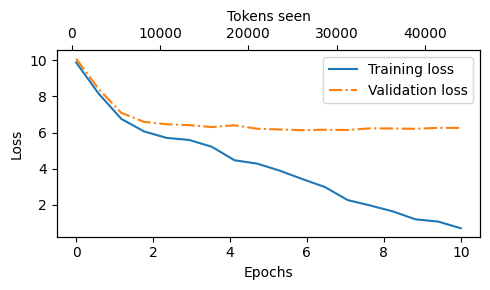

In [105]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [106]:
#Modify the text generation to include temp and top-k
def generate(model,idx,max_new_tokens,context_size,temperature=0.0,top_k=None,eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond= idx[:,-context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:,-1,:]

    if top_k is not None:
      top_logits,_ = torch.topk(logits,top_k) #Keep top k only
      min_val = top_logits[:,-1]
      logits = torch.where(logits<min_val,torch.tensor(float('-inf')).to(logits.device),logits)
    if temperature>0.0:
      logits = logits / temperature #Flatten the peaks
      logits = logits - logits.max(dim=-1,keepdim=True).values # For numerical stability
      probs = torch.softmax(logits,dim=-1) #get probalities
      idx_next = torch.multinomial(probs,num_samples=1) #get one from sample
    else:
      idx_next = torch.argmax(logits,dim=-1,keepdim=True)

    if idx_next == eos_id:
      break
    idx = torch.cat((idx,idx_next),dim=1)
  return idx


In [109]:
token_ids = generate(
    model,
    text_to_token_ids('Every effort moves you',tokenizer).to(device),
    15,
    GPT_CONFIG_124M['context_length'],
    1.4,
    25
)
print(token_ids_to_text(token_ids,tokenizer))

Every effort moves you?" I could touched that he had just a to myself told Mrs. And


In [110]:
torch.save(model.state_dict(),'model.pth')

In [112]:
model1 = GPTModel(GPT_CONFIG_124M)
model1.load_state_dict(torch.load('model.pth'))
model1.to(device)
token_ids = generate(
    model1,
    text_to_token_ids('Every effort moves you',tokenizer).to(device),
    15,
    GPT_CONFIG_124M['context_length'],
    1.4,
    25
)
print(token_ids_to_text(token_ids,tokenizer))

Every effort moves you?" I couldn't dabble a cheap genius--the fact with that it


In [113]:
#Sometimes its better to store optimzers parameters as well
torch.save({
    'model_state_dict':model.state_dict(),
    'optimizer_state_dict':optimizer.state_dict()
},'model_and_optimizer.pth')

In [114]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model2 = GPTModel(GPT_CONFIG_124M)
model2.load_state_dict(checkpoint["model_state_dict"])

optimizer2 = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer2.load_state_dict(checkpoint["optimizer_state_dict"])
model2.train();